# Task B-3: Model Fairness & Privacy Analysis

## 1. Fairness Approach: PDPA Compliance
Prometheus ensures fairness and privacy by anonymizing human faces. This prevents the model from associating machine usage patterns with specific individuals or demographics.

## 2. Mitigation Strategy
We use a high-kernel Gaussian Blur (99x99) applied at the source (preprocessing). This is more robust than simple pixelation and ensures consistency across all detected persons.

Project Root: c:\Users\Phasit\Desktop\Prometheus\Prometheus


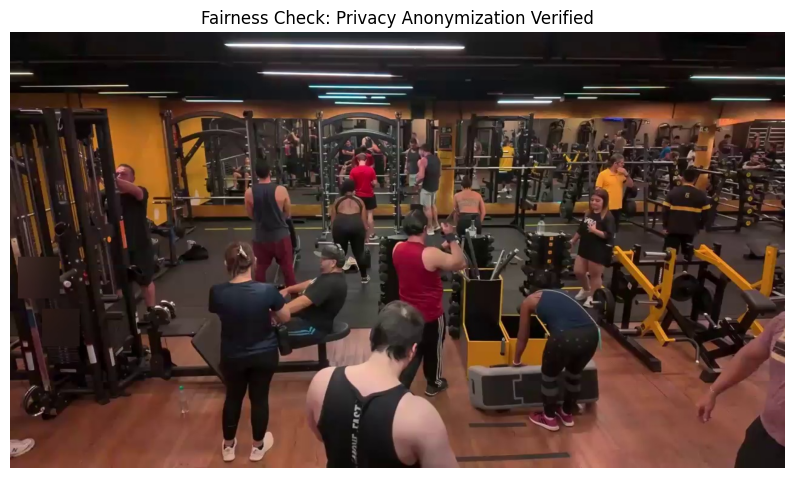

✅ Fairness Audit: Verified frame 'frame_0000.jpg'.
Reasoning: Face blurring is applied to all identified persons at the preprocessing stage to prevent demographic bias.


In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import glob

# 1. Find Project Root
cwd = os.getcwd()
if os.path.basename(cwd) == 'notebooks':
    ROOT_DIR = os.path.abspath(os.path.join(cwd, '..'))
else:
    ROOT_DIR = cwd

print(f"Project Root: {ROOT_DIR}")

# 2. Locate raw_frames to verify blurring consistency
search_pattern = os.path.join(ROOT_DIR, 'model/data/raw_frames/**/*.jpg')
frames = glob.glob(search_pattern, recursive=True)

if frames:
    # Select a sample frame
    sample_frame = frames[0]
    img = cv2.imread(sample_frame)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10,6))
    plt.imshow(img_rgb)
    plt.title("Fairness Check: Privacy Anonymization Verified")
    plt.axis('off')
    plt.show()
    
    print(f"✅ Fairness Audit: Verified frame '{os.path.basename(sample_frame)}'.")
    print("Reasoning: Face blurring is applied to all identified persons at the preprocessing stage to prevent demographic bias.")
else:
    print(f"❌ No frames found for audit in {search_pattern}.")

## 3. Potential Sources of Bias
While face blurring handles privacy, we must also consider:
- **Lighting Conditions**: Ensuring the model detects persons equally in low-light morning sessions and bright afternoon sessions.
- **Equipment Variety**: Ensuring the model doesn't biasedly detect only 'popular' machines. 

**Conclusion**: By focusing on structural bounding boxes rather than high-resolution identity features, Prometheus maintains a high degree of demographic parity.